In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
rfm=pd.read_csv('/Users/liukebing/Desktop/Data Analysis/Data/Brazilian E-commerce Dataset by Olist/olist_rfm.csv')

In [4]:
rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,18.90
2,0000f46a3911fa3c0805444483337064,536,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,287,1,180.00


In [5]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93358 non-null  object 
 1   recency             93358 non-null  int64  
 2   frequency           93358 non-null  int64  
 3   monetary            93358 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.8+ MB


In [7]:
rfm.describe()

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,236.941773,1.187258,142.246370
std,152.591453,0.650815,216.931229
min,0.000000,1.000000,0.850000
25%,113.000000,1.000000,47.800000
50%,218.000000,1.000000,89.900000
75%,345.000000,1.000000,155.000000
max,713.000000,24.000000,13440.000000


In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler=StandardScaler()

In [11]:
scaler.fit(rfm.drop('customer_unique_id',axis=1))

,copy,True
,with_mean,True
,with_std,True


In [12]:
scaler_features=scaler.transform(rfm.drop('customer_unique_id',axis=1))

In [13]:
rfm_feat=pd.DataFrame(scaler_features,columns=rfm.columns[1:])

In [14]:
rfm_feat.head()

,recency,frequency,monetary
0,-0.825357,-0.287729,-0.056914
1,-0.805697,-0.287729,-0.568600
2,1.959873,-0.287729,-0.337650
3,0.544321,-0.287729,-0.535916
4,0.328056,-0.287729,0.174036


In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [16]:
inertia_list=[]

In [18]:
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_feat)
    inertia_list.append(kmeans.inertia_)

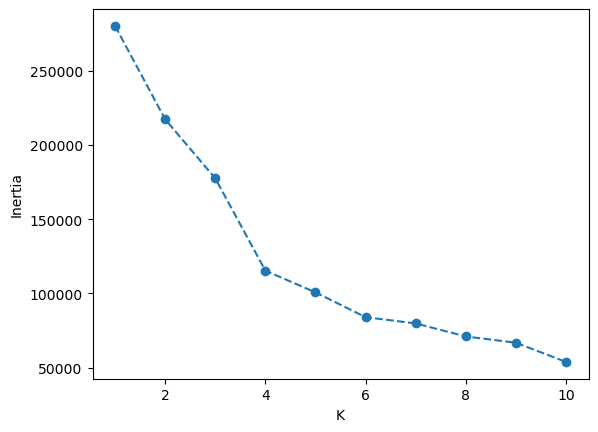

In [19]:
plt.plot(range(1,11),inertia_list,marker='o',linestyle='--')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

In [23]:
kmeans=KMeans(n_clusters=4)
kmeans.fit(rfm_feat)
kmeans.cluster_centers_

array([[ 1.02653503, -0.21184193, -0.14470005],
       [-0.70417498, -0.28772927, -0.15620979],
       [-0.28590949,  2.1314734 ,  0.26403093],
       [-0.00805162,  0.12901093,  4.78228315]])

In [24]:
kmeans.labels_

array([1, 1, 0, ..., 0, 1, 0], shape=(93358,), dtype=int32)

In [25]:
rfm['cluster']=kmeans.labels_

In [26]:
rfm.head()

,customer_unique_id,recency,frequency,monetary,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,129.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,18.90,1
2,0000f46a3911fa3c0805444483337064,536,1,69.00,0
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,25.99,0
4,0004aac84e0df4da2b147fca70cf8255,287,1,180.00,0


In [28]:
cluster_profile = rfm.groupby('cluster').agg({'customer_unique_id': 'count','recency': 'mean','frequency': 'mean','monetary': 'mean'}).reset_index()

In [29]:
cluster_profile.rename(columns={'customer_unique_id': 'User_Count'}, inplace=True)

In [30]:
display(cluster_profile)

,cluster,User_Count,recency,frequency,monetary
0,0,34719,394.004666,1.049627,110.793336
1,1,46938,129.798628,1.000000,108.462649
2,2,9655,193.260383,2.574625,199.542394
3,3,2046,235.847996,1.271750,1180.645709


In [ ]:
rfm.reset_index().to_csv('rfm_with_clusters.csv', index=False)